In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

from scipy import stats

from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Locate the repository root and Explorer Dataset folder
possible_roots = [Path.cwd()] + list(Path.cwd().parents[:6])

repo_root = None

for candidate in possible_roots:

    if (candidate / "data" / "Explorer Dataset").exists():

        repo_root = candidate
        break

# Fallback to the project location used in the capstone environment
if repo_root is None:

    repo_root = Path(
        r"d:\term 5 capstone\capstone offical github repo\Capstone_Project-DAMO-6994-"
    )

INPUT_FOLDER = repo_root / "data" / "Explorer Dataset"

FILE_PATH = INPUT_FOLDER / "ED_Visits.csv"

print("Resolved root:")
print(repo_root)

print("\nInput folder:")
print(INPUT_FOLDER)

print("\nInput file:")
print(FILE_PATH)

print("\nFile exists:", FILE_PATH.exists())

Resolved root:
c:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-

Input folder:
c:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\data\Explorer Dataset

Input file:
c:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-\data\Explorer Dataset\ED_Visits.csv

File exists: True


In [3]:
assert FILE_PATH.exists(), (
    "ED_Visits.csv not found. "
    "Update FILE_PATH before proceeding."
)

df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [4]:
print("FIRST 10 ROWS")
print("-" * 80)

display(df.head(10))

FIRST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,triage_level,ctas_urgency_score,visit_disposition,main_problem,admission_status,ed_visits,median_los_minutes,median_los_hours,admission_flag
0,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Acute Myocardial Infarction,Admitted,1360,93,1.5500,1
1,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Any,Admitted,77562,420,7.0000,1
2,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Asthma,Admitted,822,456,7.6000,1
3,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Influenzal Pneumonia,Admitted,0,0,0.0000,1
4,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Motor Vehicle Collisions,Admitted,3032,324,5.4000,1
5,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Pneumonia,Admitted,1656,561,9.3500,1
6,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Trauma,Admitted,8476,348,5.8000,1
7,2021-2022,2021,CTAS I - Resuscitation,1,Admitted,Unintentional Falls,Admitted,2393,456,7.6000,1
8,2021-2022,2021,CTAS I - Resuscitation,1,Death,Acute Myocardial Infarction,Not Admitted,365,36,0.6000,0
9,2021-2022,2021,CTAS I - Resuscitation,1,Death,Any,Not Admitted,11081,42,0.7000,0


In [5]:
print("LAST 10 ROWS")
print("-" * 80)

display(df.tail(10))

LAST 10 ROWS
--------------------------------------------------------------------------------


,fiscal_year,fiscal_year_start,triage_level,ctas_urgency_score,visit_disposition,main_problem,admission_status,ed_visits,median_los_minutes,median_los_hours,admission_flag
7286,2003-2004,2003,Non-urgent,3,Unknown,Pneumonia,Not Admitted,0,79,1.3200,0
7287,2003-2004,2003,Unknown,3,Unknown,Pneumonia,Not Admitted,0,0,0.0000,0
7288,2003-2004,2003,CTAS III - Urgent,3,Unknown,Trauma,Not Admitted,3007,67,1.1200,0
7289,2003-2004,2003,Less urgent,3,Unknown,Trauma,Not Admitted,6660,60,1.0000,0
7290,2003-2004,2003,Non-urgent,3,Unknown,Trauma,Not Admitted,109,41,0.6800,0
7291,2003-2004,2003,Unknown,3,Unknown,Trauma,Not Admitted,0,0,0.0000,0
7292,2003-2004,2003,CTAS III - Urgent,3,Unknown,Unintentional Falls,Not Admitted,895,85,1.4200,0
7293,2003-2004,2003,Less urgent,3,Unknown,Unintentional Falls,Not Admitted,1557,69,1.1500,0
7294,2003-2004,2003,Non-urgent,3,Unknown,Unintentional Falls,Not Admitted,18,42,0.7000,0
7295,2003-2004,2003,Unknown,3,Unknown,Unintentional Falls,Not Admitted,0,0,0.0000,0


In [6]:
print("DATASET SHAPE")
print("-" * 80)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

DATASET SHAPE
--------------------------------------------------------------------------------
Rows    : 7,296
Columns : 11


In [7]:
print("COLUMN NAMES")
print("-" * 80)

for i, column in enumerate(df.columns, start=1):

    print(f"{i:02d}. {column}")

COLUMN NAMES
--------------------------------------------------------------------------------
01. fiscal_year
02. fiscal_year_start
03. triage_level
04. ctas_urgency_score
05. visit_disposition
06. main_problem
07. admission_status
08. ed_visits
09. median_los_minutes
10. median_los_hours
11. admission_flag


In [8]:
print("DATA TYPES")
print("-" * 80)

display(
    pd.DataFrame({
        "Column": df.columns,
        "Data_Type": df.dtypes.astype(str).values
    })
)

DATA TYPES
--------------------------------------------------------------------------------


,Column,Data_Type
0,fiscal_year,str
1,fiscal_year_start,int64
2,triage_level,str
3,ctas_urgency_score,int64
4,visit_disposition,str
5,main_problem,str
6,admission_status,str
7,ed_visits,int64
8,median_los_minutes,int64
9,median_los_hours,float64


In [9]:
print("MISSING VALUES")
print("-" * 80)

missing_summary = pd.DataFrame({

    "Column": df.columns,

    "Missing_Count": [
        df[col].isna().sum()
        for col in df.columns
    ],

    "Missing_Percentage": [
        df[col].isna().mean() * 100
        for col in df.columns
    ]

})

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Percentage"]
    .round(2)
)

display(missing_summary)

MISSING VALUES
--------------------------------------------------------------------------------


,Column,Missing_Count,Missing_Percentage
0,fiscal_year,0,0.0000
1,fiscal_year_start,0,0.0000
2,triage_level,0,0.0000
3,ctas_urgency_score,0,0.0000
4,visit_disposition,0,0.0000
5,main_problem,0,0.0000
6,admission_status,0,0.0000
7,ed_visits,0,0.0000
8,median_los_minutes,0,0.0000
9,median_los_hours,0,0.0000


In [10]:
duplicate_count = df.duplicated().sum()

print("DUPLICATE RECORDS")
print("-" * 80)

print(f"Duplicate rows: {duplicate_count:,}")

print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(df) * 100:.2f}%"
)

DUPLICATE RECORDS
--------------------------------------------------------------------------------
Duplicate rows: 0
Duplicate percentage: 0.00%


In [11]:
print("NUMERICAL SUMMARY")
print("-" * 80)

display(
    df.describe(
        include="all"
    ).T
)

NUMERICAL SUMMARY
--------------------------------------------------------------------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fiscal_year,7296,19,2021-2022,384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fiscal_year_start,"7,296.0000",NaN,NaN,NaN,"2,012.0000",5.4776,"2,003.0000","2,007.0000","2,012.0000","2,017.0000","2,021.0000"
triage_level,7296,6,CTAS I - Resuscitation,1216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ctas_urgency_score,"7,296.0000",NaN,NaN,NaN,2.5000,0.7638,1.0000,2.0000,3.0000,3.0000,3.0000
visit_disposition,7296,8,Admitted,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_problem,7296,8,Acute Myocardial Infarction,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_status,7296,2,Not Admitted,6384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ed_visits,"7,296.0000",NaN,NaN,NaN,"61,269.2453","371,614.6321",0.0000,0.0000,95.0000,"2,859.5000","6,393,422.0000"
median_los_minutes,"7,296.0000",NaN,NaN,NaN,163.5152,167.8496,0.0000,22.7500,139.0000,233.0000,"2,583.0000"
median_los_hours,"7,296.0000",NaN,NaN,NaN,2.7253,2.7975,0.0000,0.3775,2.3200,3.8800,43.0500


In [12]:
print("FISCAL YEAR COVERAGE")
print("-" * 80)

fiscal_years = (
    df[
        ["fiscal_year_start", "fiscal_year"]
    ]
    .drop_duplicates()
    .sort_values("fiscal_year_start")
)

display(fiscal_years)

print("\nRecords per fiscal year")

display(
    df["fiscal_year"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("fiscal_year")
    .reset_index(name="record_count")
)

FISCAL YEAR COVERAGE
--------------------------------------------------------------------------------


,fiscal_year_start,fiscal_year
6912,2003,2003-2004
6528,2004,2004-2005
6144,2005,2005-2006
5760,2006,2006-2007
5376,2007,2007-2008
4992,2008,2008-2009
4608,2009,2009-2010
4224,2010,2010-2011
3840,2011,2011-2012
3456,2012,2012-2013



Records per fiscal year


,fiscal_year,record_count
0,2003-2004,384
1,2004-2005,384
2,2005-2006,384
3,2006-2007,384
4,2007-2008,384
5,2008-2009,384
6,2009-2010,384
7,2010-2011,384
8,2011-2012,384
9,2012-2013,384


In [13]:
print("FISCAL YEAR VS VISIT DISPOSITION")
print("-" * 80)

fiscal_disposition_check = pd.crosstab(
    df["fiscal_year_start"],
    df["visit_disposition"]
)

display(fiscal_disposition_check)

FISCAL YEAR VS VISIT DISPOSITION
--------------------------------------------------------------------------------


visit_disposition,Admitted,Death,Discharged Home,Intra-Facility Transfer,Not Seen Or Left,Total,Transferred,Unknown
fiscal_year_start,,,,,,,,
2003,48,48,48,48,48,48,48,48
2004,48,48,48,48,48,48,48,48
2005,48,48,48,48,48,48,48,48
2006,48,48,48,48,48,48,48,48
2007,48,48,48,48,48,48,48,48
2008,48,48,48,48,48,48,48,48
2009,48,48,48,48,48,48,48,48
2010,48,48,48,48,48,48,48,48
2011,48,48,48,48,48,48,48,48


In [14]:
print("ED VISITS AND LOS SUMMARY")
print("-" * 80)

selected_columns = [
    "fiscal_year",
    "fiscal_year_start",
    "visit_disposition",
    "admission_status",
    "ed_visits",
    "median_los_minutes",
    "median_los_hours"
]

display(
    df[selected_columns]
    .describe(include="all")
    .T
)

ED VISITS AND LOS SUMMARY
--------------------------------------------------------------------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fiscal_year,7296,19,2021-2022,384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fiscal_year_start,"7,296.0000",NaN,NaN,NaN,"2,012.0000",5.4776,"2,003.0000","2,007.0000","2,012.0000","2,017.0000","2,021.0000"
visit_disposition,7296,8,Admitted,912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_status,7296,2,Not Admitted,6384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ed_visits,"7,296.0000",NaN,NaN,NaN,"61,269.2453","371,614.6321",0.0000,0.0000,95.0000,"2,859.5000","6,393,422.0000"
median_los_minutes,"7,296.0000",NaN,NaN,NaN,163.5152,167.8496,0.0000,22.7500,139.0000,233.0000,"2,583.0000"
median_los_hours,"7,296.0000",NaN,NaN,NaN,2.7253,2.7975,0.0000,0.3775,2.3200,3.8800,43.0500


In [15]:
print("INVALID VALUE CHECKS")
print("=" * 80)

print(
    "ED visits <= 0:",
    (df["ed_visits"] <= 0).sum()
)

print(
    "LOS < 0:",
    (df["median_los_minutes"] < 0).sum()
)

print(
    "Missing fiscal year:",
    df["fiscal_year"].isna().sum()
)

print(
    "Missing fiscal year start:",
    df["fiscal_year_start"].isna().sum()
)

print(
    "Missing ED visits:",
    df["ed_visits"].isna().sum()
)

print(
    "Missing median LOS:",
    df["median_los_minutes"].isna().sum()
)

INVALID VALUE CHECKS
ED visits <= 0: 2247
LOS < 0: 0
Missing fiscal year: 0
Missing fiscal year start: 0
Missing ED visits: 0
Missing median LOS: 0


In [16]:
def weighted_mean(values, weights):

    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values) &
        np.isfinite(weights) &
        (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return np.nan

    return np.average(
        values,
        weights=weights
    )


def weighted_median(values, weights):

    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values) &
        np.isfinite(weights) &
        (weights > 0)
    )

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0:
        return np.nan

    order = np.argsort(values)

    values = values[order]
    weights = weights[order]

    cumulative_weights = np.cumsum(weights)

    midpoint = weights.sum() / 2

    return values[
        np.searchsorted(
            cumulative_weights,
            midpoint
        )
    ]

In [17]:
print("WEIGHTED DESCRIPTIVE SUMMARY")
print("-" * 80)

weighted_summary = (
    df
    .dropna(
        subset=[
            "fiscal_year",
            "ed_visits",
            "median_los_minutes"
        ]
    )
    .query("ed_visits > 0 and median_los_minutes >= 0")
    .groupby("fiscal_year")
    .apply(
        lambda x: pd.Series({

            "records":
                len(x),

            "total_ed_visits":
                x["ed_visits"].sum(),

            "weighted_mean_los_minutes":
                weighted_mean(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "weighted_median_los_minutes":
                weighted_median(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "minimum_los_minutes":
                x["median_los_minutes"].min(),

            "maximum_los_minutes":
                x["median_los_minutes"].max()

        }),
        include_groups=False
    )
    .reset_index()
)

display(weighted_summary)

WEIGHTED DESCRIPTIVE SUMMARY
--------------------------------------------------------------------------------


,fiscal_year,records,total_ed_visits,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,2003-2004,268.0000,"13,499,654.0000",135.6562,105.0000,8.0000,359.0000
1,2004-2005,266.0000,"14,396,234.0000",140.8556,109.0000,6.0000,438.0000
2,2005-2006,234.0000,"14,782,618.0000",144.2128,118.0000,12.0000,422.0000
3,2006-2007,239.0000,"14,730,506.0000",147.9203,123.0000,15.0000,649.0000
4,2007-2008,240.0000,"14,998,926.0000",162.7859,127.0000,1.0000,625.0000
5,2008-2009,266.0000,"15,044,884.0000",171.5163,146.0000,15.0000,745.0000
6,2009-2010,276.0000,"15,416,074.0000",172.6366,143.0000,14.0000,718.0000
7,2010-2011,271.0000,"21,687,972.0000",164.6893,138.0000,8.0000,932.0000
8,2011-2012,267.0000,"23,595,222.0000",165.4684,137.0000,13.0000,676.0000
9,2012-2013,275.0000,"25,642,774.0000",166.1774,143.0000,10.0000,912.0000


In [18]:
required_columns = [
    "fiscal_year",
    "fiscal_year_start",
    "ed_visits",
    "median_los_minutes"
]

print("H2 DATA VALIDATION")
print("=" * 80)

for column in required_columns:

    print(
        f"{column:25} : "
        f"{'FOUND' if column in df.columns else 'MISSING'}"
    )


analysis_df = df[
    required_columns
].copy()

analysis_df = analysis_df.dropna(
    subset=required_columns
)

analysis_df = analysis_df[
    (analysis_df["ed_visits"] > 0) &
    (analysis_df["median_los_minutes"] >= 0)
].copy()


print("\nAfter validation:")

print(
    f"Records available : {len(analysis_df):,}"
)

print(
    f"Fiscal year groups: "
    f"{analysis_df['fiscal_year'].nunique()}"
)

print(
    f"Total ED visits   : "
    f"{analysis_df['ed_visits'].sum():,.0f}"
)

print(
    f"Missing values    : "
    f"{analysis_df.isna().sum().sum()}"
)

H2 DATA VALIDATION
fiscal_year               : FOUND
fiscal_year_start         : FOUND
ed_visits                 : FOUND
median_los_minutes        : FOUND

After validation:
Records available : 5,049
Fiscal year groups: 19
Total ED visits   : 447,020,414
Missing values    : 0


In [19]:
# ============================================================
# H2 ANALYSIS DATASET
# ============================================================

PANDEMIC_YEAR = "2020-2021"
PANDEMIC_START = 2020

h2_df = analysis_df[
    analysis_df["fiscal_year_start"] <= PANDEMIC_START
].copy()

# Keep only the variables required for H2
h2_df = h2_df[
    [
        "fiscal_year",
        "fiscal_year_start",
        "ed_visits",
        "median_los_minutes"
    ]
].copy()

# Define the pandemic and preceding fiscal-year groups
pandemic_df = h2_df[
    h2_df["fiscal_year"] == PANDEMIC_YEAR
].copy()

pre_pandemic_df = h2_df[
    h2_df["fiscal_year_start"] < PANDEMIC_START
].copy()

print("=" * 80)
print("H2 ANALYSIS DATASET")
print("=" * 80)

print(f"Original records       : {len(df):,}")
print(f"Validated records      : {len(analysis_df):,}")
print(f"Records used for H2    : {len(h2_df):,}")

print(f"\nPandemic records       : {len(pandemic_df):,}")
print(f"Pre-pandemic records   : {len(pre_pandemic_df):,}")

print("\nPandemic fiscal year:")
print(sorted(pandemic_df["fiscal_year"].unique()))

print("\nPre-pandemic fiscal years:")
print(sorted(pre_pandemic_df["fiscal_year"].unique()))

print("\nExcluded fiscal years from H2:")
excluded_years = sorted(
    set(analysis_df["fiscal_year"].unique())
    - set(h2_df["fiscal_year"].unique())
)

for year in excluded_years:
    print(f"  {year}")

H2 ANALYSIS DATASET
Original records       : 7,296
Validated records      : 5,049
Records used for H2    : 4,783

Pandemic records       : 261
Pre-pandemic records   : 4,522

Pandemic fiscal year:
['2020-2021']

Pre-pandemic fiscal years:
['2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020']

Excluded fiscal years from H2:
  2021-2022


In [20]:
print("=" * 80)
print("WEIGHT VALIDATION")
print("=" * 80)

print("ED Visits data type:")
print(h2_df["ed_visits"].dtype)

print("\nNon-integer ED visit values:")

non_integer_weights = (
    h2_df["ed_visits"] % 1 != 0
).sum()

print(non_integer_weights)

print("\nMinimum ED visits:")
print(h2_df["ed_visits"].min())

print("\nMaximum ED visits:")
print(h2_df["ed_visits"].max())

print("\nTotal ED visits represented:")
print(
    f"{h2_df['ed_visits'].sum():,.0f}"
)

WEIGHT VALIDATION
ED Visits data type:
int64

Non-integer ED visit values:
0

Minimum ED visits:
5

Maximum ED visits:
6393422

Total ED visits represented:
413,442,070


In [21]:
print("H2 GROUP SUMMARY")
print("-" * 80)

def group_summary(df_group):

    return {

        "records":
            len(df_group),

        "total_ed_visits":
            df_group["ed_visits"].sum(),

        "mean_los_minutes":
            df_group["median_los_minutes"].mean(),

        "median_los_minutes":
            df_group["median_los_minutes"].median(),

        "std_los_minutes":
            df_group["median_los_minutes"].std(),

        "weighted_mean_los_minutes":
            weighted_mean(
                df_group["median_los_minutes"],
                df_group["ed_visits"]
            ),

        "weighted_median_los_minutes":
            weighted_median(
                df_group["median_los_minutes"],
                df_group["ed_visits"]
            ),

        "minimum_los_minutes":
            df_group["median_los_minutes"].min(),

        "maximum_los_minutes":
            df_group["median_los_minutes"].max()

    }


h2_summary = pd.DataFrame([

    {
        "group": "Pandemic (2020-2021)",
        **group_summary(pandemic_df)
    },

    {
        "group": "Pre-Pandemic (preceding fiscal years)",
        **group_summary(pre_pandemic_df)
    }

])

display(h2_summary)

H2 GROUP SUMMARY
--------------------------------------------------------------------------------


,group,records,total_ed_visits,mean_los_minutes,median_los_minutes,std_los_minutes,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,Pandemic (2020-2021),261,27919262,234.2874,198.0000,152.9951,204.2481,192.0000,18,1182
1,Pre-Pandemic (preceding fiscal years),4522,385522808,204.9239,179.0000,134.3331,175.3228,156.0000,1,1518


In [22]:
print("FISCAL YEAR MEDIAN LOS BREAKDOWN")
print("-" * 80)

fiscal_year_summary = (
    h2_df
    .groupby("fiscal_year")
    .agg(
        records=("median_los_minutes", "count"),
        total_ed_visits=("ed_visits", "sum"),
        mean_los_minutes=("median_los_minutes", "mean"),
        median_los_minutes=("median_los_minutes", "median"),
        std_los_minutes=("median_los_minutes", "std"),
        minimum_los_minutes=("median_los_minutes", "min"),
        maximum_los_minutes=("median_los_minutes", "max")
    )
    .reset_index()
)

display(
    fiscal_year_summary
    .sort_values("fiscal_year")
)

FISCAL YEAR MEDIAN LOS BREAKDOWN
--------------------------------------------------------------------------------


,fiscal_year,records,total_ed_visits,mean_los_minutes,median_los_minutes,std_los_minutes,minimum_los_minutes,maximum_los_minutes
0,2003-2004,268,13499654,159.8022,159.0000,74.5226,8,359
1,2004-2005,266,14396234,163.2744,161.5000,78.0015,6,438
2,2005-2006,234,14782618,173.1581,175.5000,78.0686,12,422
3,2006-2007,239,14730506,177.0711,174.0000,90.7506,15,649
4,2007-2008,240,14998926,202.2542,182.0000,116.4969,1,625
5,2008-2009,266,15044884,197.7218,170.0000,131.5209,15,745
6,2009-2010,276,15416074,205.2790,174.0000,130.8701,14,718
7,2010-2011,271,21687972,199.4096,166.0000,139.9867,8,932
8,2011-2012,267,23595222,202.2285,177.0000,124.0381,13,676
9,2012-2013,275,25642774,202.2000,176.0000,136.6821,10,912


In [23]:
# ============================================================
# MANN-WHITNEY U HYPOTHESIS TEST
# ============================================================

print("=" * 80)
print("H2 HYPOTHESIS TEST: MANN-WHITNEY U")
print("=" * 80)

pandemic_values = (
    pandemic_df["median_los_minutes"]
    .dropna()
    .values
)

pre_pandemic_values = (
    pre_pandemic_df["median_los_minutes"]
    .dropna()
    .values
)

assert len(pandemic_values) >= 2, (
    "Insufficient pandemic records for hypothesis testing."
)

assert len(pre_pandemic_values) >= 2, (
    "Insufficient pre-pandemic records for hypothesis testing."
)

u_stat, p_value = stats.mannwhitneyu(
    pandemic_values,
    pre_pandemic_values,
    alternative="two-sided"
)

ALPHA = 0.05

print(
    f"U statistic: {u_stat:.6f}"
)

print(
    f"P-value: {p_value:.10f}"
)

print(
    f"Pandemic sample size: "
    f"{len(pandemic_values):,}"
)

print(
    f"Pre-pandemic sample size: "
    f"{len(pre_pandemic_values):,}"
)

print(
    f"Significance level (α): "
    f"{ALPHA}"
)

if p_value < ALPHA:

    print("\nDecision: REJECT H₀")

    print(
        "\nConclusion:"
    )

    print(
        "There is statistically significant evidence "
        "that reported median ED length of stay differs "
        "between fiscal year 2020-2021 and the preceding "
        "fiscal years."
    )

else:

    print("\nDecision: FAIL TO REJECT H₀")

    print(
        "\nConclusion:"
    )

    print(
        "There is insufficient statistical evidence "
        "to conclude that reported median ED length "
        "of stay differs between fiscal year 2020-2021 "
        "and the preceding fiscal years."
    )

H2 HYPOTHESIS TEST: MANN-WHITNEY U
U statistic: 657784.500000
P-value: 0.0018121848
Pandemic sample size: 261
Pre-pandemic sample size: 4,522
Significance level (α): 0.05

Decision: REJECT H₀

Conclusion:
There is statistically significant evidence that reported median ED length of stay differs between fiscal year 2020-2021 and the preceding fiscal years.


In [24]:
# ============================================================
# H2 EFFECT SIZE
# ============================================================

# Rank-biserial correlation is a common effect-size measure
# for a Mann-Whitney U comparison.

n1 = len(pandemic_values)
n2 = len(pre_pandemic_values)

rank_biserial = (
    (2 * u_stat) /
    (n1 * n2)
) - 1

print("H2 EFFECT SIZE")
print("-" * 80)

print(
    f"Rank-biserial correlation: "
    f"{rank_biserial:.6f}"
)

H2 EFFECT SIZE
--------------------------------------------------------------------------------
Rank-biserial correlation: 0.114660


In [25]:
h2_result_table = pd.DataFrame({

    "Hypothesis": [
        "H2"
    ],

    "Research_Question": [
        "Does reported median ED LOS differ between fiscal year 2020-2021 and preceding fiscal years?"
    ],

    "Test": [
        "Mann-Whitney U (two-sided)"
    ],

    "U_Statistic": [
        u_stat
    ],

    "Pandemic_Sample_Size": [
        n1
    ],

    "Pre_Pandemic_Sample_Size": [
        n2
    ],

    "P_Value": [
        p_value
    ],

    "Rank_Biserial_Correlation": [
        rank_biserial
    ],

    "Alpha": [
        ALPHA
    ],

    "Decision": [
        "Reject H0"
        if p_value < ALPHA
        else "Fail to Reject H0"
    ]

})

display(h2_result_table)

,Hypothesis,Research_Question,Test,U_Statistic,Pandemic_Sample_Size,Pre_Pandemic_Sample_Size,P_Value,Rank_Biserial_Correlation,Alpha,Decision
0,H2,Does reported median ED LOS differ between fis...,Mann-Whitney U (two-sided),"657,784.5000",261,4522,0.0018,0.1147,0.0500,Reject H0


In [26]:
# Visualization settings and ordered fiscal-year data

period_labels = [
    "Pre-Pandemic",
    "Pandemic 2020-2021"
]

period_dfs = [
    pre_pandemic_df,
    pandemic_df
]

period_summary = pd.DataFrame({

    "period": period_labels,

    "records": [
        len(pre_pandemic_df),
        len(pandemic_df)
    ],

    "total_ed_visits": [
        pre_pandemic_df["ed_visits"].sum(),
        pandemic_df["ed_visits"].sum()
    ],

    "weighted_mean_los": [
        weighted_mean(
            pre_pandemic_df["median_los_minutes"],
            pre_pandemic_df["ed_visits"]
        ),
        weighted_mean(
            pandemic_df["median_los_minutes"],
            pandemic_df["ed_visits"]
        )
    ],

    "weighted_median_los": [
        weighted_median(
            pre_pandemic_df["median_los_minutes"],
            pre_pandemic_df["ed_visits"]
        ),
        weighted_median(
            pandemic_df["median_los_minutes"],
            pandemic_df["ed_visits"]
        )
    ]

})

print("H2 visualization data prepared.")

display(period_summary)

H2 visualization data prepared.


,period,records,total_ed_visits,weighted_mean_los,weighted_median_los
0,Pre-Pandemic,4522,385522808,175.3228,156.0000
1,Pandemic 2020-2021,261,27919262,204.2481,192.0000


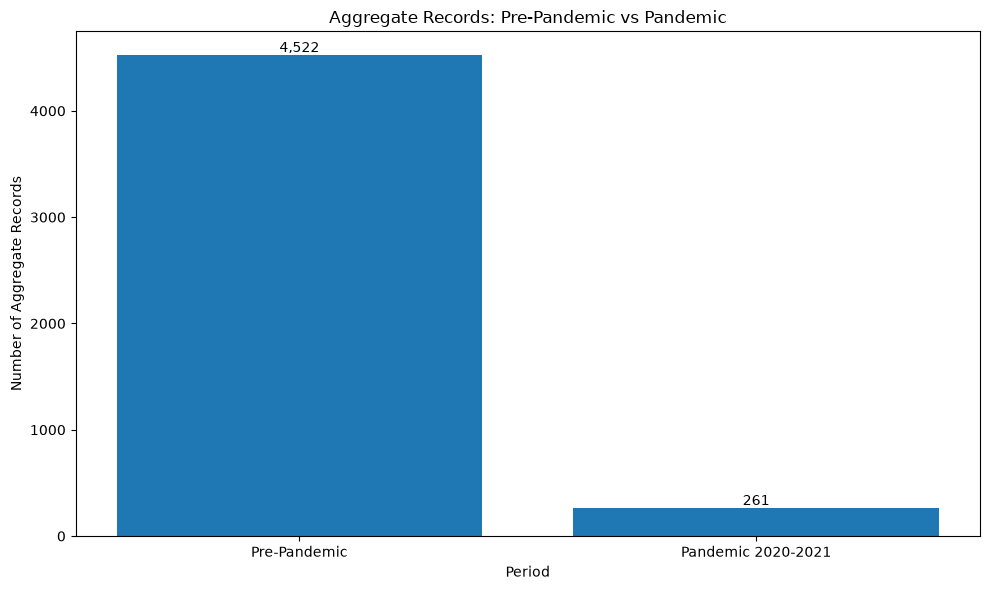

In [27]:
# NUMBER OF AGGREGATE RECORDS BY PERIOD

record_counts = period_summary["records"].values

plt.figure(figsize=(10, 6))

bars = plt.bar(
    period_labels,
    record_counts
)

plt.title(
    "Aggregate Records: Pre-Pandemic vs Pandemic"
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "Number of Aggregate Records"
)

for bar, value in zip(
    bars,
    record_counts
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

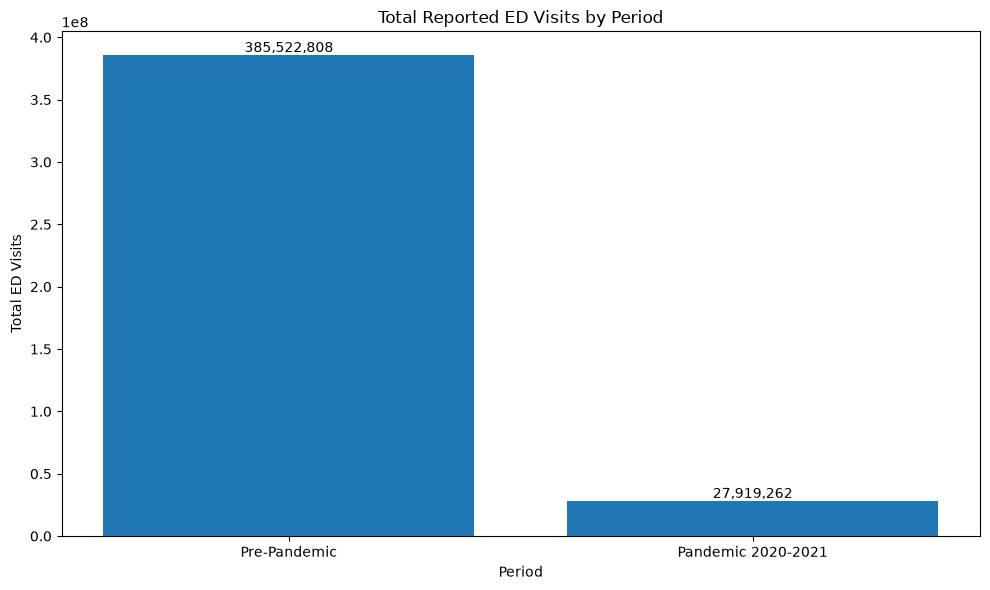

In [28]:
# TOTAL ED VISITS BY PERIOD

visit_summary = period_summary["total_ed_visits"].values

plt.figure(figsize=(10, 6))

bars = plt.bar(
    period_labels,
    visit_summary
)

plt.title(
    "Total Reported ED Visits by Period"
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "Total ED Visits"
)

for bar, value in zip(
    bars,
    visit_summary
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

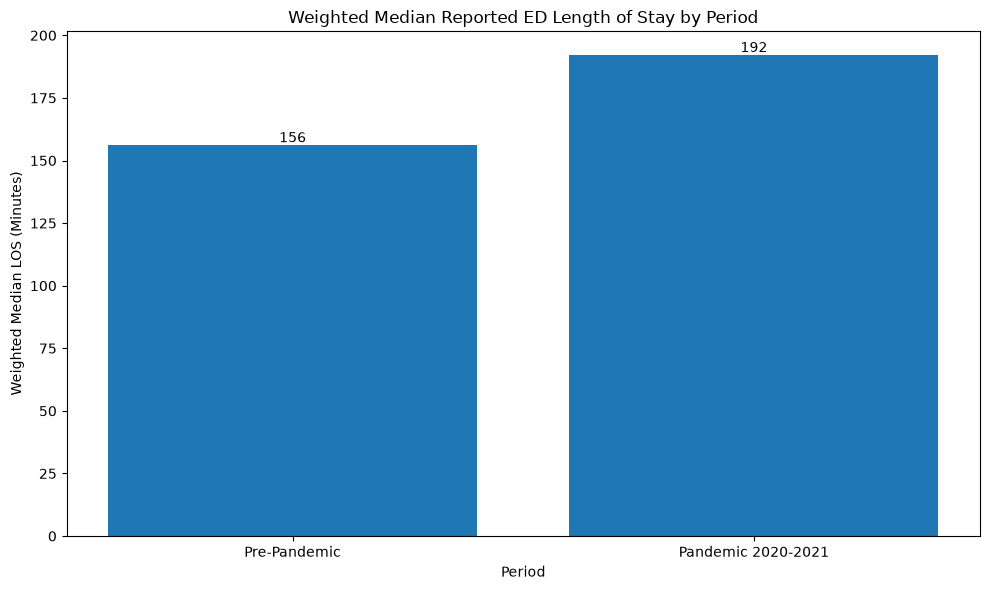

In [29]:
# WEIGHTED MEDIAN LOS BY PERIOD

weighted_los = period_summary[
    "weighted_median_los"
].values

plt.figure(figsize=(10, 6))

bars = plt.bar(
    period_labels,
    weighted_los
)

plt.title(
    "Weighted Median Reported ED Length of Stay by Period"
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "Weighted Median LOS (Minutes)"
)

for bar, value in zip(
    bars,
    weighted_los
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

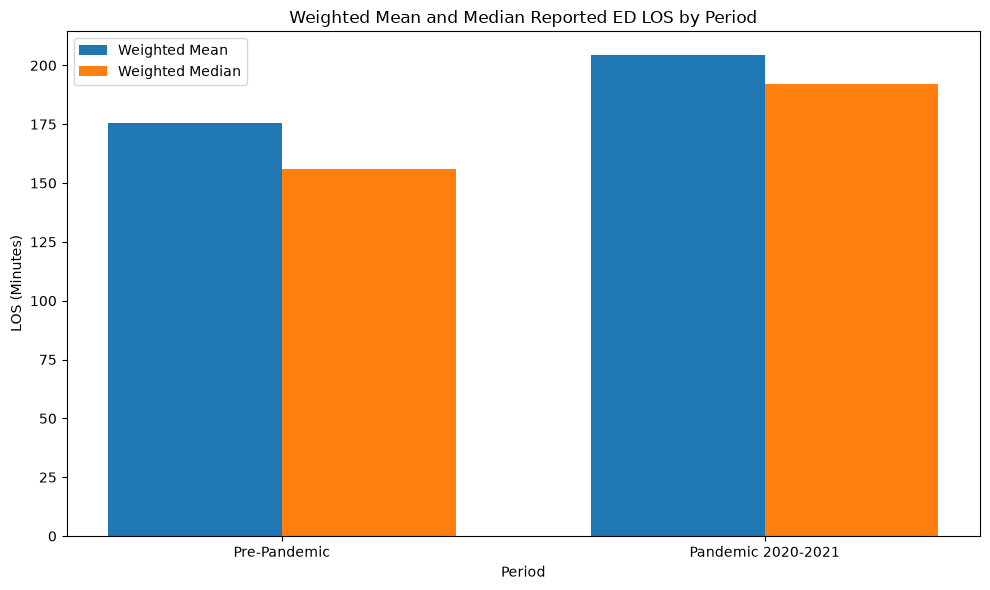

In [30]:
# WEIGHTED MEAN VS WEIGHTED MEDIAN LOS

mean_los = period_summary[
    "weighted_mean_los"
].values

median_los = period_summary[
    "weighted_median_los"
].values

x = np.arange(
    len(period_labels)
)

width = 0.36

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    mean_los,
    width,
    label="Weighted Mean"
)

plt.bar(
    x + width / 2,
    median_los,
    width,
    label="Weighted Median"
)

plt.xticks(
    x,
    period_labels
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "LOS (Minutes)"
)

plt.title(
    "Weighted Mean and Median Reported ED LOS by Period"
)

plt.legend()

plt.tight_layout()

plt.show()

In [31]:
# LOS DISTRIBUTION BY PERIOD

box_data = [
    pre_pandemic_df["median_los_minutes"].dropna().values,
    pandemic_df["median_los_minutes"].dropna().values
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    box_data,
    labels=period_labels,
    showmeans=True
)

plt.title(
    "Distribution of Reported Median ED LOS by Period"
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "Reported Median LOS (Minutes)"
)

plt.tight_layout()

plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'

<Figure size 1000x600 with 0 Axes>

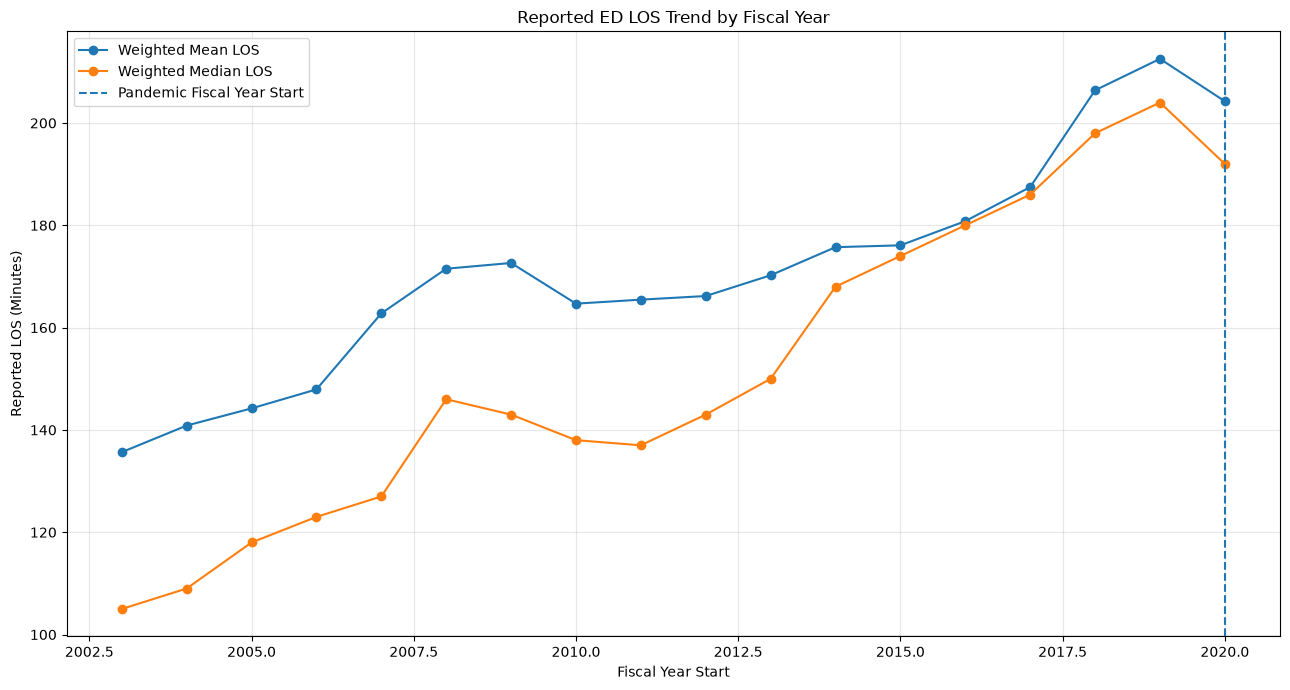

In [32]:
# REPORTED MEDIAN LOS TREND BY FISCAL YEAR

year_trend = (
    h2_df
    .groupby(
        ["fiscal_year_start", "fiscal_year"]
    )
    .apply(
        lambda x: pd.Series({

            "weighted_mean_los":
                weighted_mean(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "weighted_median_los":
                weighted_median(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "total_ed_visits":
                x["ed_visits"].sum()

        }),
        include_groups=False
    )
    .reset_index()
    .sort_values("fiscal_year_start")
)

plt.figure(figsize=(13, 7))

plt.plot(
    year_trend["fiscal_year_start"],
    year_trend["weighted_mean_los"],
    marker="o",
    label="Weighted Mean LOS"
)

plt.plot(
    year_trend["fiscal_year_start"],
    year_trend["weighted_median_los"],
    marker="o",
    label="Weighted Median LOS"
)

plt.axvline(
    PANDEMIC_START,
    linestyle="--",
    label="Pandemic Fiscal Year Start"
)

plt.title(
    "Reported ED LOS Trend by Fiscal Year"
)

plt.xlabel(
    "Fiscal Year Start"
)

plt.ylabel(
    "Reported LOS (Minutes)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

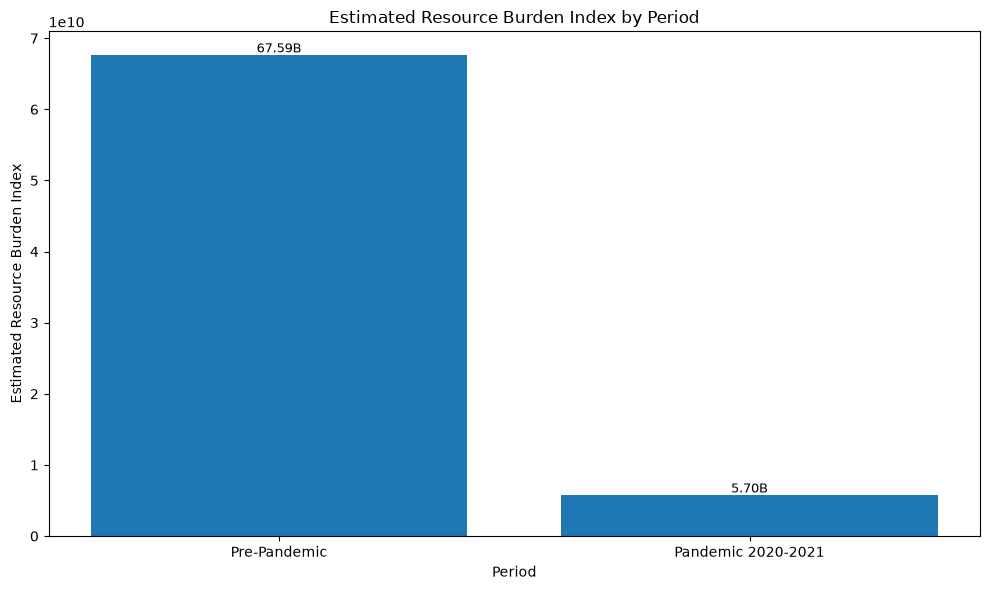

In [33]:
# ESTIMATED RESOURCE BURDEN INDEX BY PERIOD

h2_erbi = pd.Series({

    "Pre-Pandemic":
        (
            pre_pandemic_df["ed_visits"] *
            pre_pandemic_df["median_los_minutes"]
        ).sum(),

    "Pandemic 2020-2021":
        (
            pandemic_df["ed_visits"] *
            pandemic_df["median_los_minutes"]
        ).sum()

})

plt.figure(figsize=(10, 6))

bars = plt.bar(
    h2_erbi.index,
    h2_erbi.values
)

plt.title(
    "Estimated Resource Burden Index by Period"
)

plt.xlabel(
    "Period"
)

plt.ylabel(
    "Estimated Resource Burden Index"
)

for bar, value in zip(
    bars,
    h2_erbi.values
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value / 1e9:.2f}B",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

plt.show()

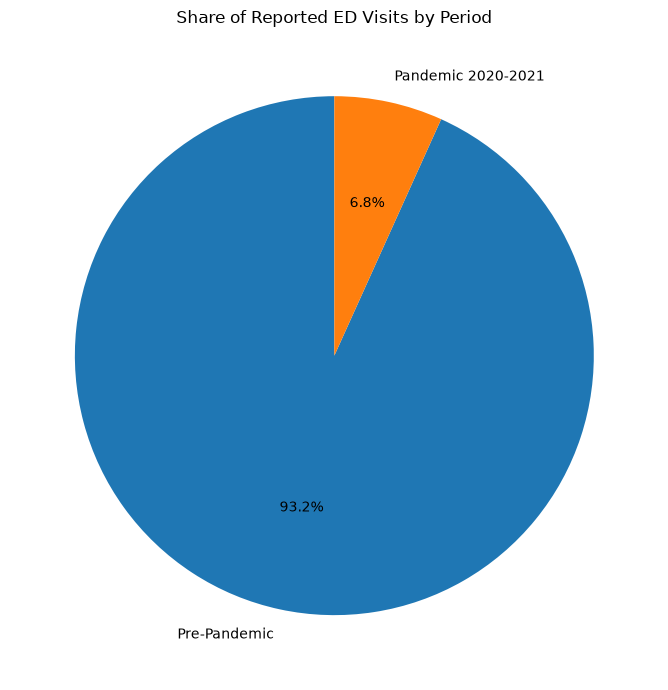

In [34]:
# ED VISIT SHARE BY PERIOD

visit_share = (
    visit_summary /
    visit_summary.sum()
) * 100

plt.figure(figsize=(9, 7))

plt.pie(
    visit_share,
    labels=period_labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Share of Reported ED Visits by Period"
)

plt.tight_layout()

plt.show()

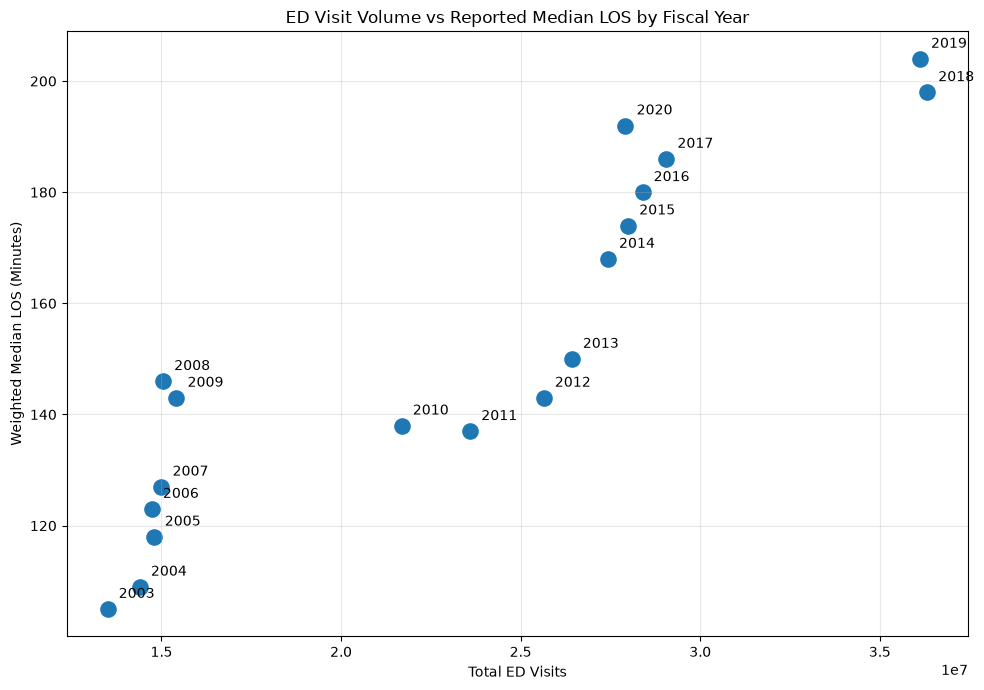

In [35]:
# ED VISIT VOLUME VS LOS BY FISCAL YEAR

scatter_data = year_trend.copy()

plt.figure(figsize=(10, 7))

plt.scatter(
    scatter_data["total_ed_visits"],
    scatter_data["weighted_median_los"],
    s=120
)

for _, row in scatter_data.iterrows():

    plt.annotate(
        str(int(row["fiscal_year_start"])),
        (
            row["total_ed_visits"],
            row["weighted_median_los"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel(
    "Total ED Visits"
)

plt.ylabel(
    "Weighted Median LOS (Minutes)"
)

plt.title(
    "ED Visit Volume vs Reported Median LOS by Fiscal Year"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

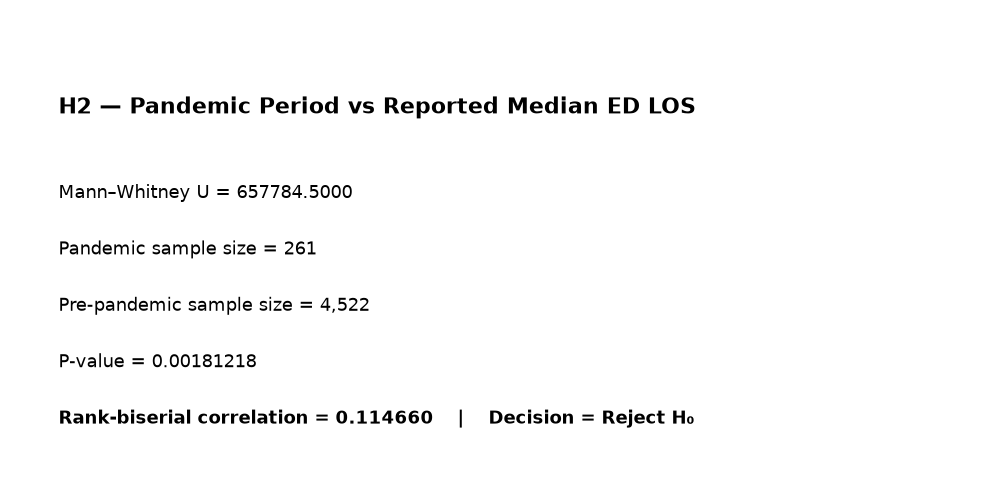

In [36]:
# H2 STATISTICAL RESULT

decision = (
    "Reject H₀"
    if p_value < ALPHA
    else
    "Fail to Reject H₀"
)

plt.figure(figsize=(10, 5))

plt.axis("off")

plt.text(
    0.05,
    0.78,
    "H2 — Pandemic Period vs Reported Median ED LOS",
    fontsize=16,
    fontweight="bold"
)

plt.text(
    0.05,
    0.60,
    f"Mann–Whitney U = {u_stat:.4f}",
    fontsize=13
)

plt.text(
    0.05,
    0.48,
    f"Pandemic sample size = {n1:,}",
    fontsize=13
)

plt.text(
    0.05,
    0.36,
    f"Pre-pandemic sample size = {n2:,}",
    fontsize=13
)

plt.text(
    0.05,
    0.24,
    f"P-value = {p_value:.6g}",
    fontsize=13
)

plt.text(
    0.05,
    0.12,
    f"Rank-biserial correlation = {rank_biserial:.6f}    |    Decision = {decision}",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Summary

This notebook used the `ED_Visits.csv` explorer dataset to compare reported median emergency department length of stay between the pandemic-affected fiscal year **2020–2021** and the preceding fiscal years.

- The workflow mirrors the H1 testing notebook: dataset inspection, validation, descriptive statistics, group summaries, formal hypothesis testing, effect size, and multiple visualizations.
- The formal test is a **two-sided Mann-Whitney U test**, because the H2 question asks whether the distributions differ without specifying an increase or decrease.
- The analysis uses only fiscal years preceding **2020–2021** for the pre-pandemic comparison.
- The final conclusion is based on whether the p-value is below the selected significance threshold of **0.05**.